In [1]:
import os
import time
import pandas as pd
import numpy as np
import warnings
import joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import ParameterSampler, TimeSeriesSplit, cross_val_score
from sklearn.preprocessing   import StandardScaler
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.metrics         import (classification_report, confusion_matrix, 
                                     f1_score, precision_score, recall_score, 
                                     roc_auc_score, average_precision_score, 
                                     precision_recall_curve, accuracy_score)

# ============================================================
# SETUP DIRECTORIES
# ============================================================
SAVE_DIR = '/kaggle/working/knn_saved_models/'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Save directory : {SAVE_DIR}\n")

# ============================================================
print("============================================================")
print("BLOCK 1: LOADING DATASET")
print("============================================================")
start_time = time.time()
df = pd.read_csv('/kaggle/input/datasets/rithishwars/ml-final-dataset/Final_Topology_Dataset_FULL_0_to_5__2.csv')
df = df.sort_values('time_window').reset_index(drop=True)

# Impute with 0. Extreme numbers destroy KNN distance math.
X = df.drop(columns=['um','dm','time_window','violation_next_window']).replace([np.inf,-np.inf],np.nan).fillna(0)
y = df['violation_next_window']

load_time = time.time() - start_time
total_samples = len(X)
violations = y.sum()

print(f"  Loaded in      : {load_time:.1f}s")
print(f"  Total samples  : {total_samples:,}")
print(f"  Features       : {X.shape[1]}")
print(f"  Violation rate : {(violations/total_samples)*100:.2f}%")
print(f"  Normal         : {total_samples - violations:,}")
print(f"  Violated       : {violations:,}\n")

# ============================================================
print("============================================================")
print("BLOCK 2: TEMPORAL SPLIT (80/15/5)")
print("============================================================")
n = len(X)
split1 = int(n * 0.95)
split2 = int(split1 * 0.80)

X_train, y_train = X.iloc[:split2], y.iloc[:split2]
X_test,  y_test  = X.iloc[split2:split1], y.iloc[split2:split1]
X_unseen, y_unseen = X.iloc[split1:], y.iloc[split1:]

print(f"  Train  : {len(X_train):,} | Violations: {y_train.sum():,} ({(y_train.sum()/len(X_train))*100:.2f}%)")
print(f"  Test   : {len(X_test):,} | Violations: {y_test.sum():,} ({(y_test.sum()/len(X_test))*100:.2f}%)")
print(f"  Unseen : {len(X_unseen):,} | Violations: {y_unseen.sum():,} ({(y_unseen.sum()/len(X_unseen))*100:.2f}%)\n")

# ============================================================
print("============================================================")
print("BLOCK 3: FEATURE SCALING")
print("============================================================")
scaler = StandardScaler()
X_train_s  = scaler.fit_transform(X_train)  
X_test_s   = scaler.transform(X_test)
X_unseen_s = scaler.transform(X_unseen)

joblib.dump(scaler, f"{SAVE_DIR}scaler.pkl")

print(f"  Post-scale mean : {X_train_s.mean():.6f}")
print(f"  Post-scale std  : {X_train_s.std():.6f}")
print(f"  scaler.pkl      : Saved\n")

# ============================================================
print("============================================================")
print("BLOCK 4: CLASS IMBALANCE STRATEGY")
print("============================================================")
print("  Strategy : Temporal Subsampling + Distance Weighting")
print("             Keep all temporal sequences intact.")
print("             Utilize weights='distance' for localized imbalance.")
tune_size = int(len(X_train) * 0.20)
X_tune_s  = X_train_s[-tune_size:]
y_tune    = y_train.iloc[-tune_size:]
print(f"  Tuning Subsample : {tune_size:,} rows (Most recent 20%)\n")

# ============================================================
print("============================================================")
print("BLOCK 5: RANDOMIZED HYPERPARAMETER SEARCH — 5 TRIALS")
print("============================================================")
print("  Sampler    : Randomized Search Equivalent")
print("  Objective  : Maximize Val F1 (TimeSeriesSplit CV)")
print("  Parameters : n_neighbors, metric")
print("-" * 60)

param_grid = {
    'n_neighbors' : [5, 11, 15, 21], 
    'weights'     : ['distance'], 
    'metric'      : ['euclidean', 'manhattan', 'cosine'] 
}

N_TRIALS = 5
param_list = list(ParameterSampler(param_grid, n_iter=N_TRIALS, random_state=42))
tscv = TimeSeriesSplit(n_splits=3)

trial_results = []
best_score = -1
best_params = None

for i, params in enumerate(param_list):
    trial_start = time.time()
    
    knn = KNeighborsClassifier(**params, n_jobs=-1)
    scores = cross_val_score(knn, X_tune_s, y_tune, cv=tscv, scoring='f1', n_jobs=-1)
    mean_f1 = scores.mean()
    
    trial_time = time.time() - trial_start
    
    print(f"\n  Trial {i+1:02d}/{N_TRIALS:02d} | k={params['n_neighbors']} | metric={params['metric']}")
    print(f"  Trial {i+1:02d}/{N_TRIALS:02d} | Val F1: {mean_f1:.4f} | Time: {trial_time:.1f}s")
    
    trial_results.append({
        'trial': i+1,
        'k': params['n_neighbors'],
        'metric': params['metric'],
        'val_f1': mean_f1,
        'time_s': trial_time
    })
    
    if mean_f1 > best_score:
        best_score = mean_f1
        best_params = params

print("\n============================================================")
print("SEARCH COMPLETE")
print(f"  Best Val F1    : {best_score:.4f}")
print(f"  Best Params    :")
for k, v in best_params.items():
    print(f"    {k:<18}: {v}")
print("============================================================\n")

# ============================================================
print("============================================================")
print("BLOCK 6: TRIAL RESULTS")
print("============================================================")
print("ALL TRIALS RANKED BY VAL F1:")
print("-" * 85)
results_df = pd.DataFrame(trial_results).sort_values('val_f1', ascending=False)
print(results_df.to_string(index=False))
results_df.to_csv(f"{SAVE_DIR}all_trial_results.csv", index=False)
print("\n  all_trial_results.csv : Saved\n")

# ============================================================
print("============================================================")
print("BLOCK 7: RETRAINING BEST MODEL (FULL BASELINE)")
print("============================================================")
print(f"  Architecture  : KNN")
print(f"  Metric        : {best_params['metric']}")
print(f"  K-Neighbors   : {best_params['n_neighbors']}")
print(f"  Training Size : {len(X_train):,}")

final_knn = KNeighborsClassifier(**best_params, n_jobs=-1)
fit_start = time.time()
final_knn.fit(X_train_s, y_train)

joblib.dump(final_knn, f"{SAVE_DIR}knn_best_model.pkl")

print(f"  Model trained in {time.time()-fit_start:.2f}s")
print(f"  knn_best_model.pkl : Saved\n")

# ============================================================
print("============================================================")
print("BLOCK 8: THRESHOLD OPTIMIZATION")
print("============================================================")
print("  Predicting on Test set to optimize threshold...")
y_prob_test   = final_knn.predict_proba(X_test_s)[:, 1]
pre, rec, thr = precision_recall_curve(y_test, y_prob_test)
f1_thr        = 2*pre*rec / (pre+rec+1e-9)
best_thr      = thr[np.argmax(f1_thr[:-1])]

print(f"  Metric : F1 Score on validation set")
print(f"  Optimal threshold (F1) : {best_thr:.4f}\n")

# ============================================================
print("============================================================")
print("BLOCK 9: FINAL EVALUATION (UNSEEN VAULT)")
print("============================================================")
y_prob_unseen = final_knn.predict_proba(X_unseen_s)[:, 1]
y_pred_unseen = (y_prob_unseen >= best_thr).astype(int)

auprc_unseen     = average_precision_score(y_unseen, y_prob_unseen)
auroc_unseen     = roc_auc_score(y_unseen, y_prob_unseen)
f1_unseen        = f1_score(y_unseen, y_pred_unseen, zero_division=0)
recall_unseen    = recall_score(y_unseen, y_pred_unseen, zero_division=0)
precision_unseen = precision_score(y_unseen, y_pred_unseen, zero_division=0)
acc_unseen       = accuracy_score(y_unseen, y_pred_unseen)

print("  Metric                 Optimal Threshold")
print("  ────────────────────────────────────────────────────────")
print(f"  AUPRC                  {auprc_unseen:.4f}")
print(f"  AUROC                  {auroc_unseen:.4f}")
print(f"  F1 Score               {f1_unseen:.4f}")
print(f"  Precision              {precision_unseen:.4f}")
print(f"  Recall (Catch Rate)    {recall_unseen:.4f}")
print(f"  Accuracy               {acc_unseen:.4f}\n")

print("  Classification Report at Optimal Threshold:")
print(classification_report(y_unseen, y_pred_unseen, target_names=['Normal','Violation']))

# ============================================================
print("============================================================")
print("BLOCK 10: FINAL SUMMARY")
print("============================================================")
print(f"  SAVE STRUCTURE:")
print(f"  {SAVE_DIR}")
print("    knn_best_model.pkl")
print("    scaler.pkl")
print("    all_trial_results.csv")

print("\n  FINAL METRICS (UNSEEN):")
print(f"    Test AUPRC         : {auprc_unseen:.4f}")
print(f"    Test AUROC         : {auroc_unseen:.4f}")
print(f"    Test F1 (optimal)  : {f1_unseen:.4f}")
print(f"    Test Recall        : {recall_unseen:.4f}")
print(f"    Test Precision     : {precision_unseen:.4f}")
print(f"    Accuracy (optimal) : {acc_unseen:.4f}")
print(f"    Optimal threshold  : {best_thr:.4f}")

print("\n============================================================")
print("ALL BLOCKS COMPLETE.")
print("============================================================")

Save directory : /kaggle/working/knn_saved_models/

BLOCK 1: LOADING DATASET
  Loaded in      : 2.6s
  Total samples  : 178,930
  Features       : 44
  Violation rate : 5.13%
  Normal         : 169,752
  Violated       : 9,178

BLOCK 2: TEMPORAL SPLIT (80/15/5)
  Train  : 135,986 | Violations: 6,916 (5.09%)
  Test   : 33,997 | Violations: 1,762 (5.18%)
  Unseen : 8,947 | Violations: 500 (5.59%)

BLOCK 3: FEATURE SCALING
  Post-scale mean : -0.000000
  Post-scale std  : 1.000000
  scaler.pkl      : Saved

BLOCK 4: CLASS IMBALANCE STRATEGY
  Strategy : Temporal Subsampling + Distance Weighting
             Keep all temporal sequences intact.
             Utilize weights='distance' for localized imbalance.
  Tuning Subsample : 27,197 rows (Most recent 20%)

BLOCK 5: RANDOMIZED HYPERPARAMETER SEARCH — 5 TRIALS
  Sampler    : Randomized Search Equivalent
  Objective  : Maximize Val F1 (TimeSeriesSplit CV)
  Parameters : n_neighbors, metric
---------------------------------------------------

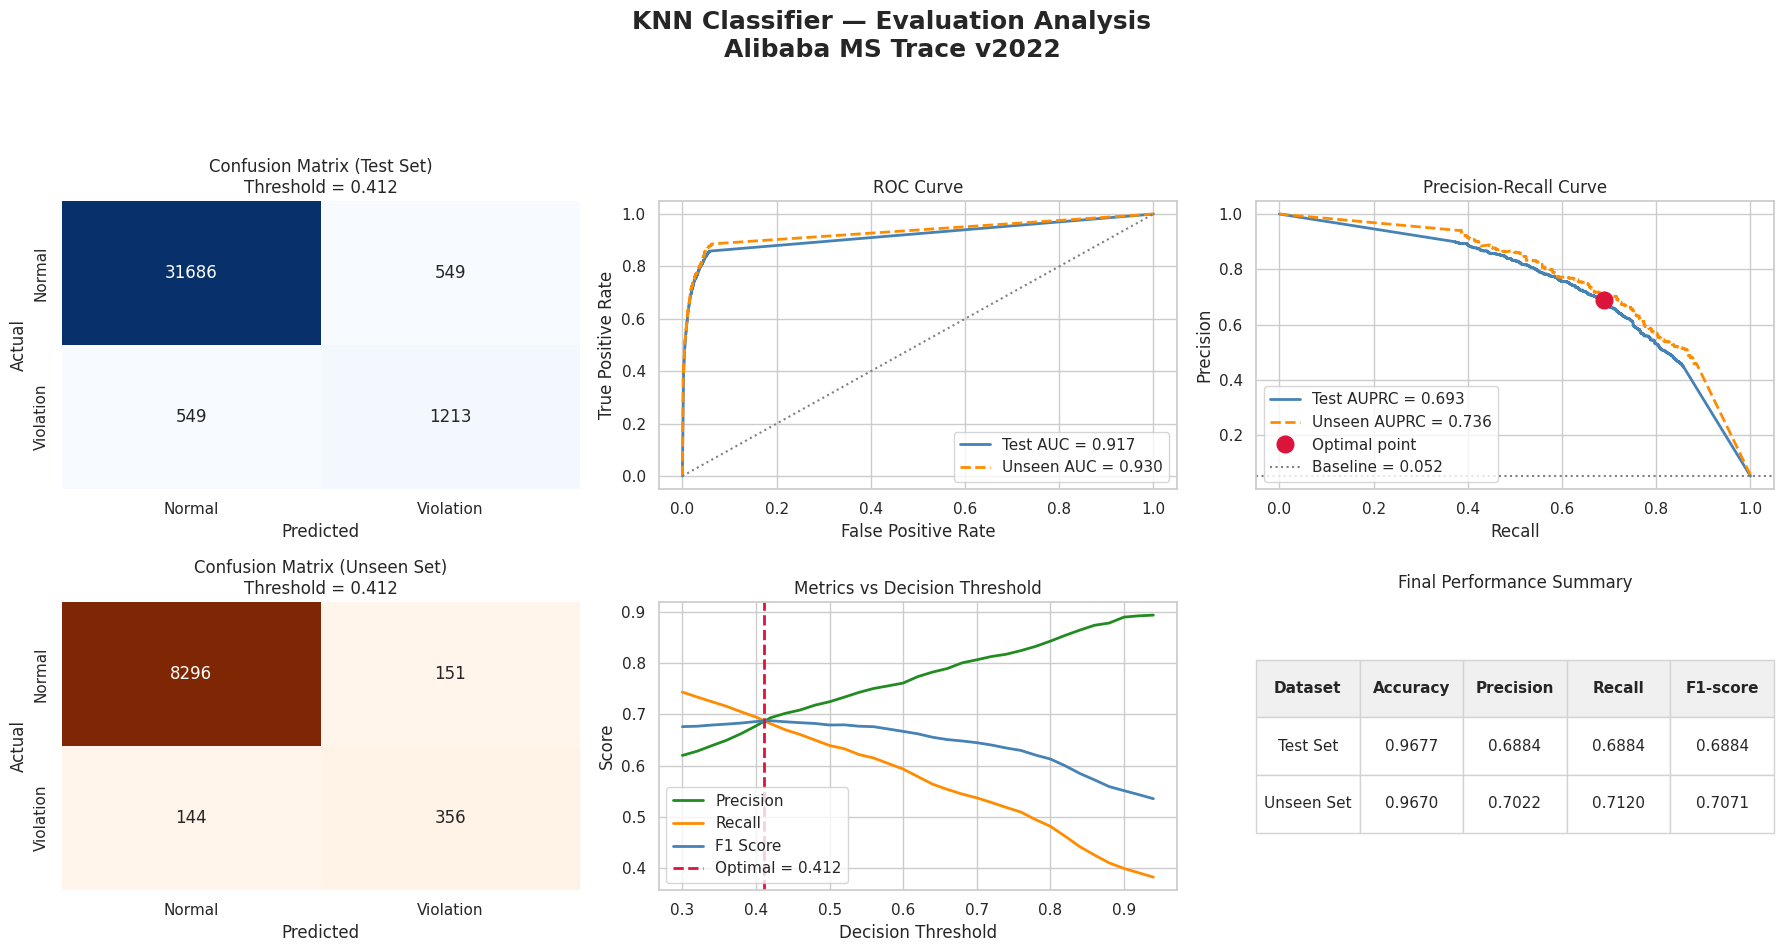


✅ Dashboard successfully generated and saved to:
  /kaggle/working/KNN_results/knn_full_analysis_dashboard.png


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, roc_curve, auc, precision_recall_curve,
    average_precision_score, precision_score, recall_score,
    f1_score, accuracy_score
)

# =================================================
# SETUP & VARIABLE CHECK
# =================================================
save_path = "/kaggle/working/KNN_results"
os.makedirs(save_path, exist_ok=True)

# Guarantee the predictions exist using the optimal threshold
y_pred_test   = (y_prob_test >= best_thr).astype(int)
y_pred_unseen = (y_prob_unseen >= best_thr).astype(int)

# Set the visual theme to match the MLP image (white background with grid)
sns.set_theme(style="whitegrid")

# Create a large dashboard canvas (2 rows, 3 columns)
fig = plt.figure(figsize=(18, 10))
fig.suptitle('KNN Classifier — Evaluation Analysis\nAlibaba MS Trace v2022', fontsize=18, fontweight='bold', y=0.98)

# =================================================
# PLOT 1: CONFUSION MATRIX (TEST)
# =================================================
ax1 = plt.subplot(2, 3, 1)
cm_test = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'Violation'], yticklabels=['Normal', 'Violation'],
            annot_kws={"size": 12})
ax1.set_title(f"Confusion Matrix (Test Set)\nThreshold = {best_thr:.3f}", fontsize=12)
ax1.set_xlabel("Predicted")
ax1.set_ylabel("Actual")

# =================================================
# PLOT 2: ROC CURVE
# =================================================
ax2 = plt.subplot(2, 3, 2)
fpr_t, tpr_t, _ = roc_curve(y_test, y_prob_test)
fpr_u, tpr_u, _ = roc_curve(y_unseen, y_prob_unseen)
auc_t = auc(fpr_t, tpr_t)
auc_u = auc(fpr_u, tpr_u)

ax2.plot(fpr_t, tpr_t, label=f"Test AUC = {auc_t:.3f}", color='steelblue', linewidth=2)
ax2.plot(fpr_u, tpr_u, linestyle="--", label=f"Unseen AUC = {auc_u:.3f}", color='darkorange', linewidth=2)
ax2.plot([0,1],[0,1], linestyle=":", color="gray")
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("ROC Curve", fontsize=12)
ax2.legend(loc='lower right')

# =================================================
# PLOT 3: PRECISION-RECALL CURVE (With Red Dot)
# =================================================
ax3 = plt.subplot(2, 3, 3)
pre_t, rec_t, thr_t = precision_recall_curve(y_test, y_prob_test)
pre_u, rec_u, _     = precision_recall_curve(y_unseen, y_prob_unseen)
pr_auc_t = average_precision_score(y_test, y_prob_test)
pr_auc_u = average_precision_score(y_unseen, y_prob_unseen)

ax3.plot(rec_t, pre_t, label=f"Test AUPRC = {pr_auc_t:.3f}", color='steelblue', linewidth=2)
ax3.plot(rec_u, pre_u, linestyle="--", label=f"Unseen AUPRC = {pr_auc_u:.3f}", color='darkorange', linewidth=2)

# Find coordinates for the optimal threshold and plot the red dot
opt_idx = np.argmin(np.abs(thr_t - best_thr))
ax3.plot(rec_t[opt_idx], pre_t[opt_idx], marker='o', markersize=12, color='crimson', label='Optimal point', linestyle='None')

ax3.axhline(y_test.mean(), linestyle=":", color="gray", label=f"Baseline = {y_test.mean():.3f}")
ax3.set_xlabel("Recall")
ax3.set_ylabel("Precision")
ax3.set_title("Precision-Recall Curve", fontsize=12)
ax3.legend(loc='lower left')

# =================================================
# PLOT 4: CONFUSION MATRIX (UNSEEN)
# =================================================
ax4 = plt.subplot(2, 3, 4)
cm_unseen = confusion_matrix(y_unseen, y_pred_unseen)
sns.heatmap(cm_unseen, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Normal', 'Violation'], yticklabels=['Normal', 'Violation'],
            annot_kws={"size": 12})
ax4.set_title(f"Confusion Matrix (Unseen Set)\nThreshold = {best_thr:.3f}", fontsize=12)
ax4.set_xlabel("Predicted")
ax4.set_ylabel("Actual")

# =================================================
# PLOT 5: THRESHOLD METRICS (With Dashed Line)
# =================================================
ax5 = plt.subplot(2, 3, 5)
thresholds_plot = np.arange(0.30, 0.95, 0.02)
p_list, r_list, f_list = [], [], []

for t in thresholds_plot:
    preds = (y_prob_test >= t).astype(int)
    p_list.append(precision_score(y_test, preds, zero_division=0))
    r_list.append(recall_score(y_test, preds, zero_division=0))
    f_list.append(f1_score(y_test, preds, zero_division=0))

ax5.plot(thresholds_plot, p_list, label="Precision", color='forestgreen', linewidth=2)
ax5.plot(thresholds_plot, r_list, label="Recall", color='darkorange', linewidth=2)
ax5.plot(thresholds_plot, f_list, label="F1 Score", color='steelblue', linewidth=2)

# Add the red dashed line for the optimal threshold
ax5.axvline(best_thr, color='crimson', linestyle='--', linewidth=2, label=f"Optimal = {best_thr:.3f}")

ax5.set_xlabel("Decision Threshold")
ax5.set_ylabel("Score")
ax5.set_title("Metrics vs Decision Threshold", fontsize=12)
ax5.legend(loc='lower left')

# =================================================
# PLOT 6: PERFORMANCE SUMMARY TABLE
# =================================================
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')

summary_df = pd.DataFrame({
    "Dataset": ["Test Set", "Unseen Set"],
    "Accuracy": [f"{accuracy_score(y_test, y_pred_test):.4f}", f"{accuracy_score(y_unseen, y_pred_unseen):.4f}"],
    "Precision": [f"{precision_score(y_test, y_pred_test):.4f}", f"{precision_score(y_unseen, y_pred_unseen):.4f}"],
    "Recall": [f"{recall_score(y_test, y_pred_test):.4f}", f"{recall_score(y_unseen, y_pred_unseen):.4f}"],
    "F1-score": [f"{f1_score(y_test, y_pred_test):.4f}", f"{f1_score(y_unseen, y_pred_unseen):.4f}"]
})

table = ax6.table(
    cellText=summary_df.values,
    colLabels=summary_df.columns,
    cellLoc='center',
    loc='center',
    bbox=[0, 0.2, 1, 0.6] # Adjust table dimensions to fit the subplot
)

table.auto_set_font_size(False)
table.set_fontsize(11)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#f0f0f0') # Light gray header
    cell.set_edgecolor('#d3d3d3')

ax6.set_title("Final Performance Summary", fontsize=12, pad=10)

# =================================================
# FINALIZE & SAVE
# =================================================
# Adjust layout to prevent overlap and make room for suptitle
plt.tight_layout(rect=[0, 0.03, 1, 0.92])

output_file = f"{save_path}/knn_full_analysis_dashboard.png"
plt.savefig(output_file, dpi=200, bbox_inches='tight')
plt.show()

print(f"\n✅ Dashboard successfully generated and saved to:\n  {output_file}")